# K-Bio 모달리티 로테이션 전략

국내 바이오 산업은 시기에 따라 주도하는 기술 테마가 달라집니다.
어떤 해에는 CDMO가 강하고, 어떤 해에는 ADC나 플랫폼 기술이 앞서기도 합니다.

이 프로젝트에서는 모달리티별 대표 종목을 모아 놓고
최근 흐름이 상대적으로 강한 자산에 더 높은 비중을 주는 전략을 만들어,
단순히 네 종목을 똑같이 나눠 갖는 것보다 나은지 확인해보았습니다.

## 진행 순서
1. 분석 조건 설정
2. 공통 함수 정의
3. 데이터 수집
4. 모멘텀 점수 계산
5. 비중 결정
6. 백테스트
7. 성과 비교
8. 안전자산 규칙 점검
9. 회전율 점검
10. 구간을 나눠서 다시 확인
11. 거래비용 민감도
12. 파라미터 비교
13. 기준값을 촘촘히 확인
14. 종목 간 상관관계 확인
15. 개별 종목 변동성 확인
16. 변동성을 반영한 비중 배분
17. 한계와 배운 점

## 기본 조건
- 분석 종료일: 2026년 8월 3일 (고정)
- 리밸런싱: 월 1회
- 거래비용: 0.1% 가정
- 비교 대상: 위험자산 4종 동일비중 보유

## 1. 분석 조건 설정

나중에 값을 바꿔가며 비교할 예정이라
조건을 한 곳에 모아두었습니다.

In [136]:
import FinanceDataReader as fdr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (14, 6)

START_DATE = "2020-01-01"
END_DATE = "2026-08-03"
LOOKBACK_MONTHS = 6
FEE_RATE = 0.001
SAFE_ASSET = "Cash"

### 종료일을 고정한 이유

처음에는 종료일을 지정하지 않고 코드를 작성했습니다.
그런데 4월에 한 번, 8월에 한 번 같은 코드를 실행했더니
결과가 상당히 다르게 나왔습니다.

원인을 찾아보니 종료일을 비워두면 실행하는 날까지
데이터를 계속 받아오기 때문이었습니다.
이러면 누가 언제 실행하느냐에 따라 숫자가 달라져서
결과를 다시 확인할 수 없습니다.

그래서 종료일을 2026년 8월 3일로 고정했습니다.
4월 시점과 8월 시점의 차이가 얼마나 컸는지는
10번 항목에서 따로 정리했습니다.

## 2. 공통 함수 정의

분석 전체에서 반복해서 쓸 함수를 먼저 만들어 두겠습니다.

In [137]:
# 한 종목의 종가만 불러옵니다.
def fetch_close_price(ticker, start_date, end_date):
    df = fdr.DataReader(ticker, start_date, end_date)
    return df["Close"]


# 여러 종목의 종가를 하나의 표로 합칩니다.
def build_price_table(ticker_map, start_date, end_date):
    price_df = pd.DataFrame()

    for ticker in ticker_map:
        name = ticker_map[ticker]
        price_df[name] = fetch_close_price(ticker, start_date, end_date)

    # 한 종목이라도 값이 없는 날은 빼겠습니다.
    price_df = price_df.dropna()
    return price_df


# 일별 수익률을 계산합니다.
def calc_daily_returns(price_df):
    return price_df.pct_change().fillna(0)


# 각 달의 마지막 거래일을 찾습니다.
# 다음 거래일의 월이 지금과 다르면, 오늘이 그 달의 마지막 거래일입니다.
def get_month_end_dates(price_df):
    all_dates = list(price_df.index)
    month_end_dates = []

    for i in range(len(all_dates)):
        current_date = all_dates[i]

        # 데이터의 맨 마지막 날은 비교할 다음 날이 없습니다.
        if i == len(all_dates) - 1:
            month_end_dates.append(current_date)
        else:
            next_date = all_dates[i + 1]
            if current_date.month != next_date.month:
                month_end_dates.append(current_date)

    return month_end_dates


# 특정 날짜의 바로 다음 거래일을 찾습니다.
def get_next_trading_day(price_index, date):
    all_dates = list(price_index)
    idx = all_dates.index(date)

    if idx + 1 < len(all_dates):
        return all_dates[idx + 1]
    else:
        return None

## 3. 데이터 수집

바이오 핵심 모달리티별로 대표 종목을 하나씩 골랐습니다.
하락장에 대비할 자산으로 국고채 ETF를 하나 추가했습니다.

| 구분 | 종목 | 코드 | 역할 |
|---|---|---|---|
| CDMO | 삼성바이오로직스 | 207940 | 위탁개발생산 |
| ADC | 리가켐바이오 | 141080 | 항체약물접합체 |
| Platform | 알테오젠 | 196170 | 플랫폼 기술 |
| Medical AI | 루닛 | 328130 | 의료 인공지능 |
| Cash | KODEX 국고채10년 | 152380 | 안전자산 |

종목을 고르는 과정에 제 판단이 들어갔다는 점은
17번 항목에서 따로 다루겠습니다.

In [138]:
ticker_map = {
    "207940": "CDMO",
    "141080": "ADC",
    "196170": "Platform",
    "328130": "Medical_AI",
    "152380": "Cash"
}

prices = build_price_table(ticker_map, START_DATE, END_DATE)

print("데이터 시작일 :", prices.index.min().date())
print("데이터 종료일 :", prices.index.max().date())
print("전체 거래일 수 :", len(prices), "일")
print()
display(prices.tail())

데이터 시작일 : 2022-07-21
데이터 종료일 : 2026-08-03
전체 거래일 수 : 985 일



,CDMO,ADC,Platform,Medical_AI,Cash
Date,,,,,
2026-07-28,1549000,90600,296500,9170.0,64755
2026-07-29,1479000,82900,282500,9000.0,64965
2026-07-30,1527000,77900,279500,8520.0,64540
2026-07-31,1485000,87500,308500,9250.0,65025
2026-08-03,1423000,95400,317500,9970.0,65020


### 확인

시작일을 2020년 1월로 넣었는데 실제 데이터는 2022년 7월부터 시작합니다.

다섯 종목이 모두 존재하는 날만 남기도록 했는데,
루닛의 상장 시점이 가장 늦어서 그 날짜가 전체 시작일이 되었습니다.

즉 백테스트 기간이 약 4년으로 짧은 것은
제가 정한 것이 아니라 종목 구성에 따라 자동으로 정해진 결과입니다.
표본이 짧으면 결과가 특정 시기의 영향을 크게 받을 수 있습니다.

데이터 마지막 날(2026-08-03)도 월말로 잡히지만,
다음 거래일이 없어 비중 계산에는 사용되지 않습니다.

## 4. 모멘텀 점수 계산

점수를 매기는 방식은 다음과 같습니다.

매월 말 기준으로 현재 가격을
1개월 전부터 6개월 전까지의 가격과 하나씩 비교합니다.
현재 가격이 더 높으면 1점을 주고, 총 6번 비교한 뒤 6으로 나눕니다.

따라서 점수는 0, 1/6, 2/6, 3/6, 4/6, 5/6, 1 중 하나가 됩니다.

이 점수는 "얼마나 많이 올랐는가"가 아니라
"최근 6개 구간 중 몇 번 이겼는가"를 나타냅니다.
상승 폭보다 상승의 일관성을 보는 방식이라고 할 수 있습니다.

In [139]:
def calc_momentum_score(price_df, lookback_months=6, safe_asset="Cash"):
    month_end_dates = get_month_end_dates(price_df)
    month_end_prices = price_df.loc[month_end_dates]

    # 안전자산은 점수를 매기지 않습니다.
    risky_assets = []
    for col in price_df.columns:
        if col != safe_asset:
            risky_assets.append(col)

    score_df = pd.DataFrame(index=month_end_prices.index)

    for asset in risky_assets:
        score_list = []

        for i in range(len(month_end_prices)):
            current_price = month_end_prices[asset].iloc[i]
            win_count = 0

            # 1개월 전부터 6개월 전까지 하나씩 비교합니다.
            for j in range(1, lookback_months + 1):
                if i - j >= 0:
                    past_price = month_end_prices[asset].iloc[i - j]
                    if current_price > past_price:
                        win_count = win_count + 1

            score_list.append(win_count / lookback_months)

        score_df[asset] = score_list

    score_df.index.name = "Date"
    return score_df


score_df = calc_momentum_score(prices, LOOKBACK_MONTHS, SAFE_ASSET)

print("최근 6개월 모멘텀 점수")
display(score_df.tail(6))

최근 6개월 모멘텀 점수


,CDMO,ADC,Platform,Medical_AI
Date,,,,
2026-03-31,0.166667,0.666667,0.000000,0.000000
2026-04-30,0.000000,0.333333,0.166667,1.000000
2026-05-29,0.000000,0.000000,0.333333,0.166667
2026-06-30,0.166667,0.000000,0.166667,0.000000
2026-07-31,0.500000,0.000000,0.000000,0.000000
2026-08-03,0.333333,0.166667,0.166667,0.166667


### 초기 구간은 주의해서 봐야 합니다

표본이 시작된 직후에는 비교할 과거 데이터가 부족합니다.
첫 달은 비교 대상이 하나도 없고, 두 번째 달은 하나뿐입니다.

그런데 나누는 값은 항상 6으로 고정해두었기 때문에
초기 6개월 동안은 점수가 구조적으로 낮게 나옵니다.

전체 월말 시점 수가 많지 않은 편이라
초기 구간이 차지하는 비중이 작지 않습니다.

In [140]:
print("초기 8개월 점수")
display(score_df.head(8))

print("월별 점수 합계 (앞 12개월)")
print(score_df.sum(axis=1).head(12).round(4))
print()
print("월말 시점 수 :", len(score_df), "회")
print("초기 6개월이 차지하는 비율 :", round(6 / len(score_df) * 100, 2), "%")

초기 8개월 점수


,CDMO,ADC,Platform,Medical_AI
Date,,,,
2022-07-29,0.000000,0.000000,0.000000,0.000000
2022-08-31,0.000000,0.166667,0.000000,0.000000
2022-09-30,0.000000,0.000000,0.000000,0.000000
2022-10-31,0.500000,0.000000,0.000000,0.166667
2022-11-30,0.666667,0.333333,0.000000,0.333333
2022-12-29,0.166667,0.500000,0.500000,0.500000
2023-01-31,0.000000,0.333333,0.166667,1.000000
2023-02-28,0.000000,0.500000,0.500000,1.000000


월별 점수 합계 (앞 12개월)
Date
2022-07-29    0.0000
2022-08-31    0.1667
2022-09-30    0.0000
2022-10-31    0.6667
2022-11-30    1.3333
2022-12-29    1.6667
2023-01-31    1.5000
2023-02-28    2.0000
2023-03-31    2.3333
2023-04-28    2.8333
2023-05-31    3.1667
2023-06-30    1.6667
dtype: float64

월말 시점 수 : 50 회
초기 6개월이 차지하는 비율 : 12.0 %


## 5. 비중 결정

계산한 점수를 실제 투자 비중으로 바꿉니다.

- 점수가 높은 자산일수록 높은 비중을 줍니다.
- 위험자산 점수의 합이 기준값 이하이면 안전자산에 100%를 둡니다.
- 월말에 계산한 비중은 다음 거래일부터 적용합니다.

마지막 항목이 중요합니다.
월말 종가로 계산한 비중을 같은 날에 적용하면
그날 종가를 미리 알고 매매한 것이 됩니다.
실제로는 불가능한 일이라 하루 뒤로 미뤘습니다.

기준값(threshold)과 비중 상한(max_weight)은
나중에 바꿔가며 비교하려고 인자로 빼두었습니다.
기본값을 쓰면 처음 설계한 방식 그대로 동작합니다.

In [141]:
def calc_weights(price_df, score_df, safe_asset="Cash", threshold=0.0, max_weight=1.0):
    risky_assets = list(score_df.columns)

    weights_df = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=price_df.columns,
        dtype=float
    )

    for date in score_df.index:
        scores = score_df.loc[date]
        score_sum = scores.sum()

        # 위험자산 흐름이 약하면 안전자산으로 옮깁니다.
        if score_sum <= threshold:
            weights_df.loc[date, safe_asset] = 1.0
            continue

        # 점수 비율대로 비중을 나눕니다.
        for asset in risky_assets:
            weights_df.loc[date, asset] = scores[asset] / score_sum

        # 상한을 넘는 종목은 상한까지만 담습니다.
        for asset in risky_assets:
            if weights_df.loc[date, asset] > max_weight:
                weights_df.loc[date, asset] = max_weight

        # 상한 때문에 채우지 못한 만큼은 안전자산으로 둡니다.
        used = 0.0
        for asset in risky_assets:
            used = used + weights_df.loc[date, asset]

        remain = 1.0 - used

        # 나눗셈을 여러 번 하다 보면 아주 작은 소수점 오차가 남습니다.
        # 실제로 0.0000000000000001 같은 값이 남아서
        # 현금을 들고 있는 것처럼 집계된 적이 있어 아래 처리를 넣었습니다.
        if remain < 0.000001:
            remain = 0.0

        weights_df.loc[date, safe_asset] = remain

    # 월말에 계산한 비중을 다음 거래일부터 적용합니다.
    new_index = []
    valid_rows = []

    for date in weights_df.index:
        next_day = get_next_trading_day(price_df.index, date)
        if next_day is not None:
            new_index.append(next_day)
            valid_rows.append(weights_df.loc[date].values)

    final_weights = pd.DataFrame(
        valid_rows,
        index=new_index,
        columns=weights_df.columns,
        dtype=float
    )
    final_weights.index.name = "Date"

    return final_weights


weights_df = calc_weights(prices, score_df, SAFE_ASSET)

print("최근 적용 비중")
display(weights_df.tail(6))

최근 적용 비중


,CDMO,ADC,Platform,Medical_AI,Cash
Date,,,,,
2026-03-03,0.384615,0.307692,0.000000,0.307692,0.0
2026-04-01,0.200000,0.800000,0.000000,0.000000,0.0
2026-05-04,0.000000,0.222222,0.111111,0.666667,0.0
2026-06-01,0.000000,0.000000,0.666667,0.333333,0.0
2026-07-01,0.500000,0.000000,0.500000,0.000000,0.0
2026-08-03,1.000000,0.000000,0.000000,0.000000,0.0


## 6. 백테스트

비중대로 투자했을 때 성과가 어떻게 되는지 계산합니다.

리밸런싱하는 날에는 비중이 바뀐 만큼 거래비용을 뺍니다.
바뀐 정도는 각 종목의 비중 변화를 절대값으로 더해서 구했습니다.
이 값을 회전율(turnover)이라고 부릅니다.

리밸런싱하지 않는 날에는 직전 비중을 그대로 유지합니다.

매매는 월말 종가에 체결된다고 가정했습니다.
실제로는 종가를 확인한 뒤 주문을 내야 하므로 다음 날 시가에 체결될 가능성이 높고,
그 차이만큼 결과가 달라질 수 있습니다.

In [142]:
def run_backtest(price_df, weight_df, fee_rate=0.001):
    daily_returns = calc_daily_returns(price_df)

    applied_weights = pd.DataFrame(
        np.nan,
        index=price_df.index,
        columns=price_df.columns,
        dtype=float
    )
    applied_weights.loc[weight_df.index] = weight_df

    # 리밸런싱 전까지는 직전 비중을 그대로 끌고 갑니다.
    applied_weights = applied_weights.ffill().dropna()
    daily_returns = daily_returns.loc[applied_weights.index]

    rebalance_dates = list(weight_df.index)
    portfolio_returns = []
    prev_weights = None

    for date in applied_weights.index:
        current_weights = applied_weights.loc[date]

        # 비중이 실제로 바뀐 날에만 비용을 뺍니다.
        cost = 0.0
        if prev_weights is not None:
            if date in rebalance_dates:
                turnover = abs(current_weights - prev_weights).sum()
                cost = turnover * fee_rate

        daily_return = (daily_returns.loc[date] * current_weights).sum() - cost
        portfolio_returns.append(daily_return)

        prev_weights = current_weights

    portfolio_returns = pd.Series(
        portfolio_returns,
        index=applied_weights.index,
        dtype=float
    )
    cumulative_returns = (1 + portfolio_returns).cumprod()

    return portfolio_returns, cumulative_returns, applied_weights


# 비교군은 위험자산 4종을 매달 똑같이 나눠 갖는 방식입니다.
def run_equal_weight_benchmark(price_df, safe_asset="Cash", fee_rate=0.001):
    risky_assets = []
    for col in price_df.columns:
        if col != safe_asset:
            risky_assets.append(col)

    risky_prices = price_df[risky_assets]
    month_end_dates = get_month_end_dates(risky_prices)

    rebalance_dates = []
    for date in month_end_dates:
        next_day = get_next_trading_day(risky_prices.index, date)
        if next_day is not None:
            rebalance_dates.append(next_day)

    equal_weight = 1 / len(risky_assets)

    weight_df = pd.DataFrame(
        equal_weight,
        index=rebalance_dates,
        columns=risky_assets,
        dtype=float
    )

    return run_backtest(risky_prices, weight_df, fee_rate)

## 7. 성과 비교

다음 다섯 가지로 평가하겠습니다.

- **Total Return** : 기간 전체 누적수익률
- **CAGR** : 연평균 성장률
- **MDD** : 고점 대비 최대 낙폭
- **Volatility** : 연환산 변동성
- **Sharpe** : 변동성 1단위당 수익률

수익률만 보면 위험을 얼마나 감수했는지 알 수 없어서
낙폭과 변동성을 함께 보려고 넣었습니다.

In [143]:
def evaluate_performance(daily_returns, cumulative_returns):
    total_return = cumulative_returns.iloc[-1] - 1

    # 1년을 252거래일로 보고 연환산합니다.
    cagr = cumulative_returns.iloc[-1] ** (252 / len(cumulative_returns)) - 1

    # 그동안의 최고점 대비 얼마나 떨어졌는지 계산합니다.
    running_max = cumulative_returns.cummax()
    drawdown = 1 - (cumulative_returns / running_max)
    mdd = drawdown.max()

    volatility = daily_returns.std() * np.sqrt(252)

    if daily_returns.std() != 0:
        sharpe = (daily_returns.mean() / daily_returns.std()) * np.sqrt(252)
    else:
        sharpe = np.nan

    summary = pd.Series({
        "Total Return": total_return,
        "CAGR": cagr,
        "MDD": mdd,
        "Volatility": volatility,
        "Sharpe": sharpe
    })

    return summary, drawdown


strategy_daily, strategy_cum, strategy_weights = run_backtest(
    prices, weights_df, FEE_RATE
)

bench_daily, bench_cum, bench_weights = run_equal_weight_benchmark(
    prices, SAFE_ASSET, FEE_RATE
)

strategy_summary, strategy_dd = evaluate_performance(strategy_daily, strategy_cum)
bench_summary, bench_dd = evaluate_performance(bench_daily, bench_cum)

summary_df = pd.concat(
    [strategy_summary.rename("Strategy"), bench_summary.rename("Benchmark")],
    axis=1
)
summary_df["Diff"] = summary_df["Strategy"] - summary_df["Benchmark"]

display(summary_df.round(4))

,Strategy,Benchmark,Diff
Total Return,2.6468,2.0377,0.6091
CAGR,0.3957,0.3315,0.0642
MDD,0.4958,0.4448,0.0509
Volatility,0.4928,0.4319,0.0608
Sharpe,0.9212,0.8780,0.0432


### 결과를 읽을 때 주의할 점

Diff 열이 모두 양수로 나오는데, 지표마다 의미가 다릅니다.

Total Return, CAGR, Sharpe는 양수면 전략이 나은 것이지만
MDD와 Volatility는 양수면 전략이 더 나빴다는 뜻입니다.

- CAGR : 전략이 6.42%p 높음
- Volatility : 전략이 6.08%p 높음
- MDD : 전략이 5.09%p 높음

수익이 더 난 만큼 변동성도 거의 같은 크기로 커졌습니다.
Sharpe 차이가 0.0432에 그친 것도 같은 이유입니다.

특히 MDD가 비교군보다 높다는 점은 예상과 달랐습니다.
안전자산 전환 규칙을 넣어두었으니 하락에 강할 것이라 생각했는데
실제로는 반대였습니다. 다음 항목에서 이유를 찾아보겠습니다.

## 7-1. 그래프로 확인

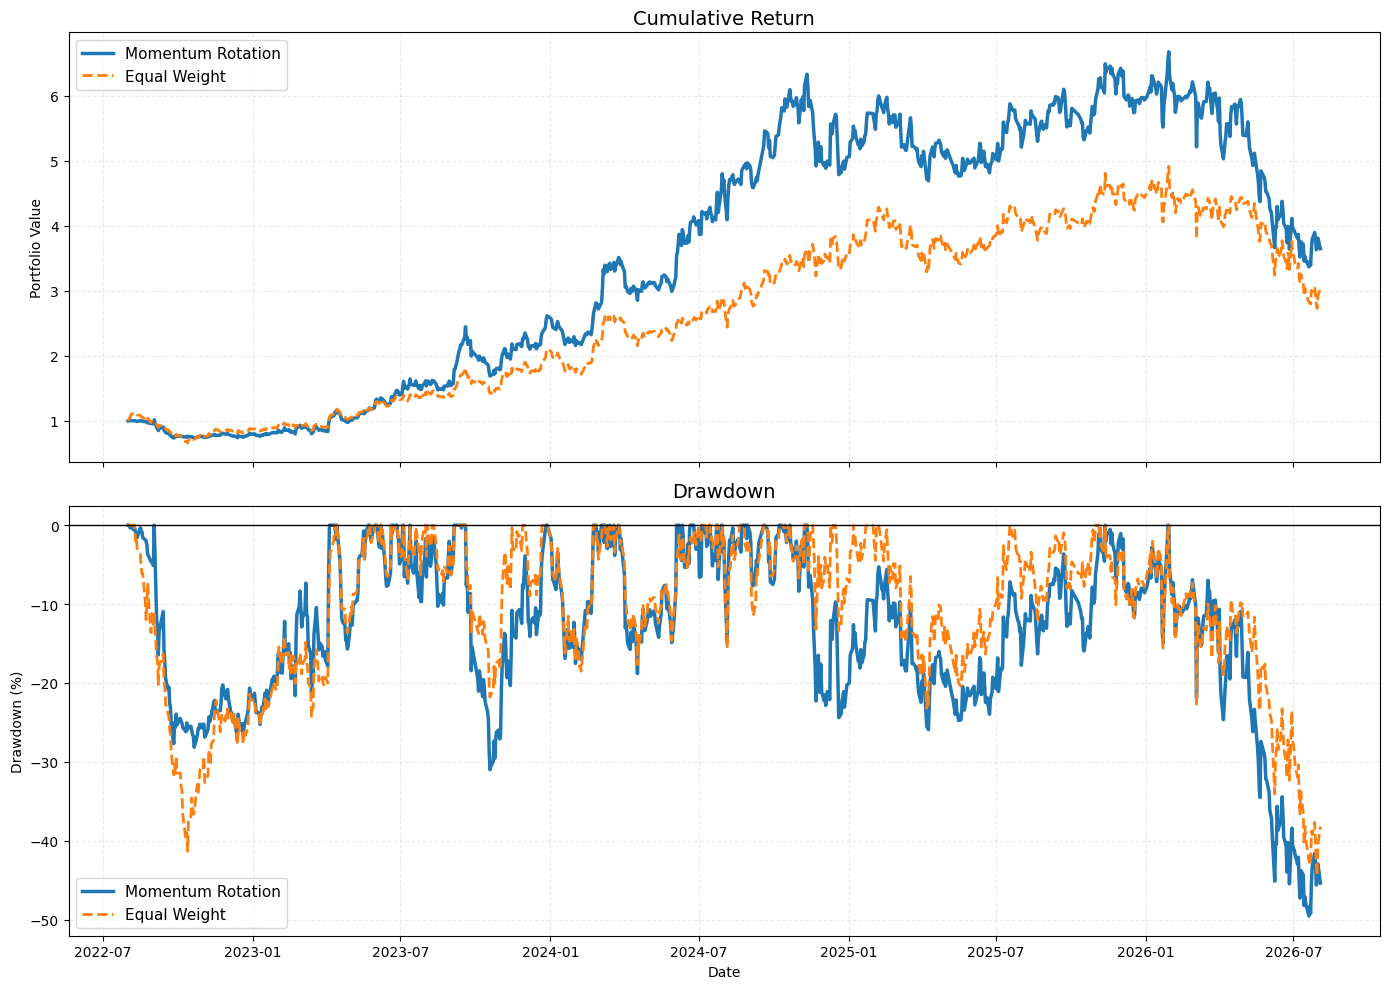

In [144]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

axes[0].plot(strategy_cum.index, strategy_cum.values,
             label="Momentum Rotation", linewidth=2.5)
axes[0].plot(bench_cum.index, bench_cum.values,
             label="Equal Weight", linewidth=2.0, linestyle="--")
axes[0].set_title("Cumulative Return", fontsize=14)
axes[0].set_ylabel("Portfolio Value")
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle="--", alpha=0.25)

# 낙폭은 아래로 내려가도록 음수로 그렸습니다.
axes[1].plot(strategy_dd.index, -strategy_dd.values * 100,
             label="Momentum Rotation", linewidth=2.5)
axes[1].plot(bench_dd.index, -bench_dd.values * 100,
             label="Equal Weight", linewidth=2.0, linestyle="--")
axes[1].axhline(0, linewidth=1, color="black")
axes[1].set_title("Drawdown", fontsize=14)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Drawdown (%)")
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

## 8. 안전자산 규칙은 언제 작동했을까

MDD가 비교군보다 높게 나온 것이 이해되지 않아서
안전자산 전환이 실제로 몇 번 일어났는지 세어보았습니다.

In [145]:
# 아주 작은 소수점 오차를 걸러내기 위해 0.0001을 기준으로 잡았습니다.
cash_days = strategy_weights[strategy_weights[SAFE_ASSET] > 0.0001]

print("전체 거래일 수 :", len(strategy_weights), "일")
print("안전자산 보유일 :", len(cash_days), "일")
print("비율 :", round(len(cash_days) / len(strategy_weights) * 100, 2), "%")

if len(cash_days) > 0:
    print()
    print("발동 시점 :", cash_days.index.min().date(), "부터", cash_days.index.max().date(), "사이")
    print("(연속 구간이 아니며, 달별 분포는 다음 셀에서 확인합니다)")
else:
    print()
    print("한 번도 발동하지 않았습니다.")

전체 거래일 수 : 978 일
안전자산 보유일 : 41 일
비율 : 4.19 %

발동 시점 : 2022-08-01 부터 2022-10-31 사이
(연속 구간이 아니며, 달별 분포는 다음 셀에서 확인합니다)


In [146]:
# 안전자산을 들고 있던 날이 어느 달에 몰려 있는지 확인해보겠습니다.
month_count = {}

for date in cash_days.index:
    key = str(date.year) + "-" + str(date.month).zfill(2)
    if key in month_count:
        month_count[key] = month_count[key] + 1
    else:
        month_count[key] = 1

print("안전자산 보유일이 있었던 달")
for key in month_count:
    print(key, ":", month_count[key], "일")

안전자산 보유일이 있었던 달
2022-08 : 22 일
2022-10 : 19 일


### 결과

978일 중 41일(4.19%), 2022년 8월과 10월에만 작동했습니다.

발동 조건이 "4종목 × 6개 시점 = 24번 비교를 전부 패배"라 지나치게 엄격했습니다.
2026년 하락에서는 일부 종목이 버티며 조건이 깨졌고, 낙폭이 가장 컸던 시기에 위험자산을 100% 보유했습니다.

8월 현금 100% → 9월 ADC 100% → 10월 현금 100%.
조건 경계에서 켜졌다 꺼지며 왕복 매매가 발생했습니다.

## 9. 회전율 확인

매달 비중을 얼마나 크게 바꾸고 있는지 보겠습니다.
회전율이 높으면 실제 운용에서 비용 부담이 커집니다.

In [147]:
turnover = strategy_weights.diff().abs().sum(axis=1).fillna(0)

# 리밸런싱이 실제로 일어난 날만 골라냅니다.
turnover_list = []
date_list = []

for date in turnover.index:
    if turnover[date] > 0:
        turnover_list.append(turnover[date])
        date_list.append(date)

print("리밸런싱 횟수 :", len(turnover_list), "회")
print("평균 turnover :", round(np.mean(turnover_list), 4))
print("중앙값 turnover :", round(np.median(turnover_list), 4))
print("최대 turnover :", round(max(turnover_list), 4))

# 회전율이 가장 컸던 날을 찾아봅니다.
max_value = max(turnover_list)
max_index = turnover_list.index(max_value)
max_date = date_list[max_index]

print()
print("회전율이 가장 컸던 날 :", max_date.date())
print("그 날의 비중")
display(strategy_weights.loc[max_date])

리밸런싱 횟수 : 48 회
평균 turnover : 0.5488
중앙값 turnover : 0.3879
최대 turnover : 2.0

회전율이 가장 컸던 날 : 2022-09-01
그 날의 비중


CDMO          0.0
ADC           1.0
Platform      0.0
Medical_AI    0.0
Cash          0.0
Name: 2022-09-01 00:00:00, dtype: float64

### 결과

48회 리밸런싱, 평균 0.5488 / 중앙값 0.3879 / 최대 2.00.

평균이 중앙값보다 큰 것은 가끔 포트폴리오를 통째로 교체하는 달이 섞여 있기 때문입니다.
최대치는 2022-09-01로, 직전 현금 100%에서 ADC 100%로 전환된 날입니다.

원인은 점수가 7개 값만 갖는다는 점, 그리고 비중 상한이 없다는 점입니다.

## 10. 구간을 나눠서 다시 확인

앞서 적었듯이 4월에 계산했을 때와 8월에 계산했을 때
결과가 크게 달랐습니다.

전략을 만들고 확인한 시점이 2026년 4월 9일이었으므로,
그 이전을 전략을 만든 구간, 그 이후를 만든 뒤 지나간 구간으로 나눠
각각의 성과를 비교해보겠습니다.

전략을 설계할 때 보지 않은 기간에서도 비슷한 성과가 나오는지
확인하기 위한 것입니다.

In [148]:
SPLIT_DATE = "2026-04-09"

# 구간별 성과를 계산하는 함수를 만들었습니다.
def evaluate_period(daily_returns, start=None, end=None):
    period_returns = daily_returns.loc[start:end]
    period_cum = (1 + period_returns).cumprod()
    summary, _ = evaluate_performance(period_returns, period_cum)
    return summary


periods = [
    ("설계 구간 (2026-04-09 이전)", None, SPLIT_DATE),
    ("이후 구간 (2026-04-10 이후)", "2026-04-10", None),
    ("전체 구간", None, None)
]

rows = []

for name, start, end in periods:
    s = evaluate_period(strategy_daily, start, end)
    b = evaluate_period(bench_daily, start, end)

    rows.append({
        "구간": name,
        "전략 수익률": round(s["Total Return"], 4),
        "비교군 수익률": round(b["Total Return"], 4),
        "전략 MDD": round(s["MDD"], 4),
        "비교군 MDD": round(b["MDD"], 4),
        "전략 Sharpe": round(s["Sharpe"], 4),
        "비교군 Sharpe": round(b["Sharpe"], 4)
    })

period_result = pd.DataFrame(rows).set_index("구간")
display(period_result)

,전략 수익률,비교군 수익률,전략 MDD,비교군 MDD,전략 Sharpe,비교군 Sharpe
구간,,,,,,
설계 구간 (2026-04-09 이전),4.3875,3.1904,0.3101,0.4134,1.2305,1.1750
이후 구간 (2026-04-10 이후),-0.3231,-0.2751,0.4338,0.3868,-1.5572,-1.4494
전체 구간,2.6468,2.0377,0.4958,0.4448,0.9212,0.8780


### 결과

| 구간 | 전략 MDD | 비교군 MDD |
|---|---|---|
| 설계 (2026-04-09 이전) | 31.01% | 41.34% |
| 이후 (2026-04-10 이후) | 43.38% | 38.68% |

우위가 뒤집혔습니다. 넉 달을 추가했을 뿐인데 결론이 반대가 됩니다.

"낙폭 방어가 된다"는 판단은 설계에 사용한 구간에서만 성립했습니다.
백테스트 성과가 전략의 성질인지 그 기간의 성질인지 구분해야 한다는 것을 확인했습니다.

## 11. 거래비용 민감도

거래비용을 0.1%로 가정했는데 이 값이 결과를 얼마나 좌우하는지
확인해보겠습니다.
실제 매매에서는 호가 차이 등으로 가정보다 비용이 더 들 수 있습니다.

In [149]:
fee_list = [0.000, 0.001, 0.002, 0.003, 0.005, 0.010]
rows = []

for fee in fee_list:
    daily, cum, _ = run_backtest(prices, weights_df, fee)
    summary, _ = evaluate_performance(daily, cum)

    rows.append({
        "거래비용": str(round(fee * 100, 2)) + "%",
        "Total Return": round(summary["Total Return"], 4),
        "CAGR": round(summary["CAGR"], 4),
        "MDD": round(summary["MDD"], 4),
        "Sharpe": round(summary["Sharpe"], 4)
    })

fee_result = pd.DataFrame(rows).set_index("거래비용")
display(fee_result)

,Total Return,CAGR,MDD,Sharpe
거래비용,,,,
0.0%,2.7440,0.4052,0.4932,0.9350
0.1%,2.6468,0.3957,0.4958,0.9212
0.2%,2.5521,0.3863,0.4984,0.9074
0.3%,2.4597,0.3769,0.5009,0.8936
0.5%,2.2818,0.3583,0.5061,0.8659
1.0%,1.8747,0.3127,0.5203,0.7963


### 결과

비용 0.1%p당 CAGR 약 0.94%p 감소. 평균 회전율 0.5488, 연 6.6회전과 부합합니다.

0.5%까지 올려도 Sharpe는 6% 감소에 그쳤습니다.
이 전략의 약점은 거래비용보다 하락 구간 방어에 있습니다.

## 12. 파라미터를 바꿔 비교하기

앞에서 확인한 두 가지를 조정해보겠습니다.

1. 안전자산 전환 조건이 너무 까다로움 → 기준값을 올려봅니다
2. 한 종목에 비중이 쏠림 → 비중 상한을 두어봅니다

수익률이 아니라 MDD와 Sharpe가 나아지는지를 중심으로 보겠습니다.
수익률이 조금 낮아지더라도 낙폭이 크게 줄어든다면
그쪽이 더 나은 결과라고 볼 수 있습니다.

참고로 위험자산이 4종목이므로 점수 합의 최대값은 4.0입니다.
기준값 1.0은 종목당 평균 점수 0.25에 해당합니다.

In [150]:
# (설정 이름, 전환 기준값, 비중 상한)
configs = [
    ("기본 설정", 0.0, 1.0),
    ("전환기준 0.5", 0.5, 1.0),
    ("전환기준 1.0", 1.0, 1.0),
    ("전환기준 1.5", 1.5, 1.0),
    ("비중상한 0.5", 0.0, 0.5),
    ("비중상한 0.4", 0.0, 0.4),
    ("기준1.0 + 상한0.4", 1.0, 0.4)
]

rows = []

for name, threshold, max_weight in configs:
    w = calc_weights(prices, score_df, SAFE_ASSET, threshold, max_weight)
    daily, cum, applied = run_backtest(prices, w, FEE_RATE)
    summary, _ = evaluate_performance(daily, cum)

    to = applied.diff().abs().sum(axis=1).fillna(0)

    to_list = []
    for date in to.index:
        if to[date] > 0:
            to_list.append(to[date])

    cash_count = (applied[SAFE_ASSET] > 0.0001).sum()

    rows.append({
        "설정": name,
        "CAGR": round(summary["CAGR"], 4),
        "MDD": round(summary["MDD"], 4),
        "Volatility": round(summary["Volatility"], 4),
        "Sharpe": round(summary["Sharpe"], 4),
        "평균 turnover": round(np.mean(to_list), 4),
        "안전자산 보유일": int(cash_count)
    })

# 비교군도 같은 표에 넣습니다.
rows.append({
    "설정": "동일비중 비교군",
    "CAGR": round(bench_summary["CAGR"], 4),
    "MDD": round(bench_summary["MDD"], 4),
    "Volatility": round(bench_summary["Volatility"], 4),
    "Sharpe": round(bench_summary["Sharpe"], 4),
    "평균 turnover": None,
    "안전자산 보유일": 0
})

param_result = pd.DataFrame(rows).set_index("설정")
display(param_result)

,CAGR,MDD,Volatility,Sharpe,평균 turnover,안전자산 보유일
설정,,,,,,
기본 설정,0.3957,0.4958,0.4928,0.9212,0.5488,41
전환기준 0.5,0.5504,0.3452,0.4577,1.1854,0.4826,105
전환기준 1.0,0.5630,0.3209,0.4481,1.2191,0.5161,149
전환기준 1.5,0.4601,0.3101,0.4190,1.1116,0.6716,249
비중상한 0.5,0.4401,0.4649,0.4668,1.0130,0.4829,228
비중상한 0.4,0.4282,0.4312,0.4382,1.0309,0.4479,494
기준1.0 + 상한0.4,0.5173,0.2960,0.4170,1.2072,0.4802,494
동일비중 비교군,0.3315,0.4448,0.4319,0.8780,NaN,0


### 결과

| 설정 | CAGR | MDD | Sharpe |
|---|---|---|---|
| 기본 | 39.57% | 49.58% | 0.9212 |
| 전환기준 1.0 | 56.30% | 32.09% | 1.2191 |
| 기준1.0 + 상한0.4 | 51.73% | 29.60% | 1.2072 |
| 비교군 | 33.15% | 44.48% | 0.8780 |

기준값 조정만으로 수익과 낙폭이 동시에 개선됐습니다.
안전자산 보유일이 41일에서 149일로 늘어난 결과입니다.

비중 상한은 단독 효과가 작았습니다. 특정 시점에 회피하는 것이 아니라 상시로 위험을 낮추는 방식이라 성격이 다릅니다.

다만 같은 데이터로 7개 설정을 비교한 뒤 선택한 것이므로, 다음 항목에서 별도 확인이 필요합니다.

### 조정한 설정이 이후 구간에서도 통하는지 확인

파라미터를 고른 근거가 설계 구간 데이터였으므로,
설계에 쓰지 않은 기간에서도 같은 방향으로 작동하는지 봐야 합니다.

In [151]:
# 개선된 설정이 이후 구간에서도 통하는지 확인해보겠습니다.
check_configs = [
    ("기본 설정", 0.0, 1.0),
    ("전환기준 1.0", 1.0, 1.0),
    ("기준1.0 + 상한0.4", 1.0, 0.4)
]

rows = []

for name, threshold, max_weight in check_configs:
    w = calc_weights(prices, score_df, SAFE_ASSET, threshold, max_weight)
    daily, cum, applied = run_backtest(prices, w, FEE_RATE)

    before = evaluate_period(daily, None, SPLIT_DATE)
    after = evaluate_period(daily, "2026-04-10", None)

    rows.append({
        "설정": name,
        "설계구간 수익률": round(before["Total Return"], 4),
        "설계구간 MDD": round(before["MDD"], 4),
        "이후구간 수익률": round(after["Total Return"], 4),
        "이후구간 MDD": round(after["MDD"], 4)
    })

# 비교군도 넣습니다.
b_before = evaluate_period(bench_daily, None, SPLIT_DATE)
b_after = evaluate_period(bench_daily, "2026-04-10", None)

rows.append({
    "설정": "동일비중 비교군",
    "설계구간 수익률": round(b_before["Total Return"], 4),
    "설계구간 MDD": round(b_before["MDD"], 4),
    "이후구간 수익률": round(b_after["Total Return"], 4),
    "이후구간 MDD": round(b_after["MDD"], 4)
})

check_result = pd.DataFrame(rows).set_index("설정")
display(check_result)

,설계구간 수익률,설계구간 MDD,이후구간 수익률,이후구간 MDD
설정,,,,
기본 설정,4.3875,0.3101,-0.3231,0.4338
전환기준 1.0,5.9550,0.3101,-0.1864,0.2193
기준1.0 + 상한0.4,4.8542,0.2960,-0.1386,0.1615
동일비중 비교군,3.1904,0.4134,-0.2751,0.3868


### 결과

| 설정 | 이후구간 수익률 | 이후구간 MDD |
|---|---|---|
| 기본 | -32.31% | 43.38% |
| 전환기준 1.0 | -18.64% | 21.93% |
| 기준1.0 + 상한0.4 | -13.86% | 16.15% |
| 비교군 | -27.51% | 38.68% |

설계 구간 데이터로 고른 기준값이 이후 구간에서도 작동했습니다.
기본 설정의 문제는 신호가 아니라 회피 조건의 엄격함에 있었다고 볼 근거가 됩니다.

단 이후 구간은 넉 달, 하락 국면 한 번입니다.

## 13. 기준값을 촘촘히 확인

앞에서는 기준값을 0.5 단위로 몇 개만 시도했습니다.
특정 값에서만 좋은 것인지 확인하기 위해 0.1 단위로 촘촘하게 계산하겠습니다.

값을 조금씩 바꿨을 때 성과가 완만하게 변한다면 규칙이 안정적이라고 볼 수 있고,
한 지점에서만 튄다면 그 값에 맞춰진 결과일 수 있습니다.

In [152]:
# 기준값을 0.1 단위로 바꿔가며 성과가 어떻게 변하는지 보겠습니다.
# 특정 값에서만 좋다면 그 값에 맞춰진 것일 수 있습니다.
threshold_list = []
value = 0.0

while value <= 2.5:
    threshold_list.append(round(value, 1))
    value = value + 0.1

rows = []

for th in threshold_list:
    w = calc_weights(prices, score_df, SAFE_ASSET, th, 1.0)
    daily, cum, applied = run_backtest(prices, w, FEE_RATE)
    summary, _ = evaluate_performance(daily, cum)

    cash_count = (applied[SAFE_ASSET] > 0.0001).sum()

    rows.append({
        "기준값": th,
        "CAGR": round(summary["CAGR"], 4),
        "MDD": round(summary["MDD"], 4),
        "Sharpe": round(summary["Sharpe"], 4),
        "안전자산 보유일": int(cash_count)
    })

threshold_result = pd.DataFrame(rows).set_index("기준값")
display(threshold_result)

,CAGR,MDD,Sharpe,안전자산 보유일
기준값,,,,
0.0,0.3957,0.4958,0.9212,41
0.1,0.3957,0.4958,0.9212,41
0.2,0.4704,0.4958,1.0361,61
0.3,0.4704,0.4958,1.0361,61
0.4,0.4800,0.4548,1.0588,83
0.5,0.5504,0.3452,1.1854,105
0.6,0.5504,0.3452,1.1854,105
0.7,0.5484,0.3452,1.1837,127
0.8,0.5484,0.3452,1.1837,127


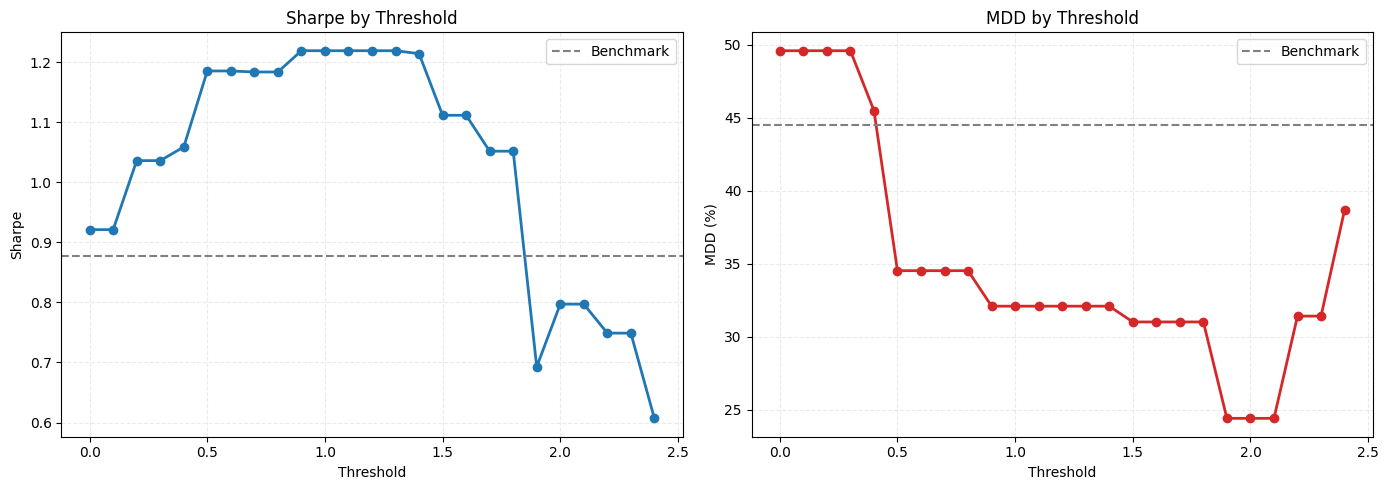

In [153]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(threshold_result.index, threshold_result["Sharpe"],
             marker="o", linewidth=2)
axes[0].axhline(bench_summary["Sharpe"], linestyle="--",
                color="gray", label="Benchmark")
axes[0].set_title("Sharpe by Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Sharpe")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.25)

axes[1].plot(threshold_result.index, threshold_result["MDD"] * 100,
             marker="o", linewidth=2, color="tab:red")
axes[1].axhline(bench_summary["MDD"] * 100, linestyle="--",
                color="gray", label="Benchmark")
axes[1].set_title("MDD by Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("MDD (%)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.25)

plt.tight_layout()
plt.show()

### 결과

계단 모양은 점수가 7개 값만 갖기 때문입니다. 기준값을 조금 옮겨도 걸리는 점수 합이 없으면 결과가 같습니다.

Sharpe 최고 구간은 0.9에서 1.3까지(1.2191), 0.5에서 1.4로 넓혀도 1.18에서 1.22를 유지합니다.
특정 값에만 맞아떨어진 결과는 아닙니다.

**MDD만 보면 오독합니다.** 기준값 1.9에서 2.1이 MDD 24.41%로 가장 낮지만, Sharpe는 0.69에서 0.80으로 비교군보다 낮습니다.
안전자산 보유일이 392일에서 458일, 전체의 40%를 넘습니다. 방어가 아니라 미참여의 결과입니다.

## 14. 종목 간 상관관계 확인

배분 규칙을 여러 방식으로 바꿔도 MDD가 30% 아래로 잘 내려가지 않았습니다.
네 종목이 모두 바이오라 서로 비슷하게 움직이는 것이 원인인지 확인하겠습니다.

In [154]:
risky_assets = []
for col in prices.columns:
    if col != SAFE_ASSET:
        risky_assets.append(col)

returns = calc_daily_returns(prices)
risky_returns = returns[risky_assets]

print("전체 기간 상관계수")
display(risky_returns.corr().round(3))

# 시장이 크게 떨어진 날만 골라서 상관을 다시 봅니다.
market = risky_returns.mean(axis=1)
threshold_down = market.quantile(0.1)

down_days = []
for date in market.index:
    if market[date] <= threshold_down:
        down_days.append(date)

print()
print("하위 10% 하락일 :", len(down_days), "일")
print("하락일 상관계수")
display(risky_returns.loc[down_days].corr().round(3))

# 평균 상관을 비교합니다.
def avg_corr(corr_df):
    total = 0.0
    count = 0
    cols = list(corr_df.columns)

    for i in range(len(cols)):
        for j in range(len(cols)):
            if i < j:
                total = total + corr_df.iloc[i, j]
                count = count + 1

    return total / count

print()
print("전체 평균 상관 :", round(avg_corr(risky_returns.corr()), 4))
print("하락일 평균 상관 :", round(avg_corr(risky_returns.loc[down_days].corr()), 4))

전체 기간 상관계수


,CDMO,ADC,Platform,Medical_AI
CDMO,1.000,0.343,0.291,0.146
ADC,0.343,1.000,0.568,0.257
Platform,0.291,0.568,1.000,0.215
Medical_AI,0.146,0.257,0.215,1.000



하위 10% 하락일 : 99 일
하락일 상관계수


,CDMO,ADC,Platform,Medical_AI
CDMO,1.000,0.252,0.191,-0.137
ADC,0.252,1.000,0.204,-0.104
Platform,0.191,0.204,1.000,-0.303
Medical_AI,-0.137,-0.104,-0.303,1.000



전체 평균 상관 : 0.3034
하락일 평균 상관 : 0.0172


### 계산 방식을 의심했습니다

전체 상관 0.3034 → 하락일 0.0172. Medical_AI는 음수까지 나왔습니다.
하락장에서 상관이 오른다는 통념과 반대입니다.

하락일을 네 종목의 평균으로 골랐기 때문입니다.
평균이 낮은 날만 모으면 한 종목이 덜 떨어질 때 다른 종목이 더 떨어져야 하므로, 음의 관계가 인위적으로 생깁니다.

포트폴리오 바깥 기준인 코스닥 지수로 다시 확인하겠습니다.

In [155]:
# 앞의 방식은 네 종목의 평균으로 하락일을 골랐습니다.
# 그런데 평균이 낮은 날만 모으면 종목끼리 서로 상쇄되는
# 관계가 인위적으로 만들어질 수 있습니다.
# 그래서 포트폴리오 바깥에 있는 코스닥 지수를 기준으로 다시 잘라보겠습니다.

kosdaq = fdr.DataReader("KQ11", START_DATE, END_DATE)["Close"]
kosdaq_ret = kosdaq.pct_change().fillna(0)

# 날짜를 맞춥니다.
common_dates = []
for date in risky_returns.index:
    if date in kosdaq_ret.index:
        common_dates.append(date)

kq = kosdaq_ret.loc[common_dates]
rr = risky_returns.loc[common_dates]

down_cut = kq.quantile(0.1)
up_cut = kq.quantile(0.9)

kq_down = []
kq_up = []

for date in kq.index:
    if kq[date] <= down_cut:
        kq_down.append(date)
    if kq[date] >= up_cut:
        kq_up.append(date)

print("코스닥 하위 10% 하락일 :", len(kq_down), "일")
print("코스닥 상위 10% 상승일 :", len(kq_up), "일")
print()
print("전체 평균 상관 :", round(avg_corr(rr.corr()), 4))
print("코스닥 하락일 평균 상관 :", round(avg_corr(rr.loc[kq_down].corr()), 4))
print("코스닥 상승일 평균 상관 :", round(avg_corr(rr.loc[kq_up].corr()), 4))
print()
print("코스닥 하락일 상관계수")
display(rr.loc[kq_down].corr().round(3))

코스닥 하위 10% 하락일 : 99 일
코스닥 상위 10% 상승일 : 99 일

전체 평균 상관 : 0.3034
코스닥 하락일 평균 상관 : 0.1972
코스닥 상승일 평균 상관 : 0.2933

코스닥 하락일 상관계수


,CDMO,ADC,Platform,Medical_AI
CDMO,1.000,0.194,0.292,0.073
ADC,0.194,1.000,0.530,0.036
Platform,0.292,0.530,1.000,0.058
Medical_AI,0.073,0.036,0.058,1.000


### 재확인 결과

| 기준 | 평균 상관 |
|---|---|
| 전체 | 0.3034 |
| 네 종목 평균으로 선별 | 0.0172 |
| 코스닥으로 선별 (하락일) | 0.1972 |
| 코스닥으로 선별 (상승일) | 0.2933 |

음수가 사라졌습니다. 0.0172는 데이터가 아니라 표본 선별 방식이 만든 값이었습니다.

하락일 상관이 상승일보다 낮은 것은 Medical_AI가 다른 종목과 0.036에서 0.073 사이로 거의 무관하게 움직였기 때문입니다.
종목 간 동조화가 낙폭의 원인은 아니었습니다.

## 15. 개별 종목 변동성 확인

상관이 원인이 아니라면 종목 자체의 움직임이 큰 것인지 확인하겠습니다.
각 종목을 단독으로 보유했을 때의 변동성과 낙폭을 계산해 포트폴리오와 비교합니다.

In [156]:
# 각 종목이 얼마나 크게 움직이는지 봅니다.
rows = []

for asset in risky_assets:
    r = risky_returns[asset]
    cum = (1 + r).cumprod()
    running_max = cum.cummax()
    dd = 1 - (cum / running_max)

    rows.append({
        "종목": asset,
        "연환산 변동성": round(r.std() * np.sqrt(252), 4),
        "단독 MDD": round(dd.max(), 4),
        "전체 수익률": round(cum.iloc[-1] - 1, 4)
    })

asset_stat = pd.DataFrame(rows).set_index("종목")
display(asset_stat)

print()
print("동일비중 포트폴리오 변동성 :", round(bench_summary["Volatility"], 4))
print("개별 변동성 평균 :", round(asset_stat["연환산 변동성"].mean(), 4))
print("분산으로 줄어든 정도 :",
      round(asset_stat["연환산 변동성"].mean() - bench_summary["Volatility"], 4))

,연환산 변동성,단독 MDD,전체 수익률
종목,,,
CDMO,0.3108,0.3674,0.1835
ADC,0.6450,0.6351,1.0672
Platform,0.7139,0.5503,4.7412
Medical_AI,0.7710,0.8532,0.1015



동일비중 포트폴리오 변동성 : 0.4319
개별 변동성 평균 : 0.6102
분산으로 줄어든 정도 : 0.1782


### 확인 결과

| 종목 | 변동성 | 단독 MDD | 수익률 |
|---|---|---|---|
| CDMO | 31.08% | 36.74% | +18.35% |
| ADC | 64.50% | 63.51% | +106.72% |
| Platform | 71.39% | 55.03% | **+474.12%** |
| Medical_AI | 77.10% | **85.32%** | +10.15% |

개별 변동성 평균 61.02% → 포트폴리오 43.19%. 분산은 작동했습니다.
낙폭이 컸던 것은 배분 방식이 아니라 종목 자체의 변동성 때문이었습니다.
(개별 종목은 데이터 전체 기간, 포트폴리오는 백테스트 기간 기준이라 며칠 차이가 있습니다.)

수익의 대부분이 Platform 한 종목에서 나왔습니다.
전략의 성과인지 종목 선택의 결과인지 현재 구성으로는 구분되지 않습니다.

## 16. 변동성을 반영한 비중 배분

15번에서 확인한 문제를 하나 조정해보겠습니다.

지금까지는 모멘텀 점수만으로 비중을 나눴습니다.
그런데 Medical_AI는 연 변동성이 77.10%이고 CDMO는 31.08%입니다.
두 종목에 같은 비중을 주면 실제로 지는 위험은 두 배 이상 차이가 납니다.

점수를 각 종목의 변동성으로 나눈 뒤 비중을 계산하면
많이 움직이는 종목의 비중이 자동으로 줄어듭니다.

변동성은 리밸런싱 시점 이전 60거래일 수익률로 계산합니다.
미래 데이터를 쓰지 않기 위해 해당 시점까지의 데이터만 사용합니다.

In [157]:
# 각 월말 시점에서 직전 60거래일 변동성을 계산합니다.
# 그 시점까지의 데이터만 쓰기 때문에 미래를 보지 않습니다.
def calc_past_volatility(price_df, score_df, window=60):
    risky_assets = list(score_df.columns)
    daily_returns = calc_daily_returns(price_df)

    vol_df = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=risky_assets,
        dtype=float
    )

    all_dates = list(price_df.index)

    for date in score_df.index:
        idx = all_dates.index(date)
        start_idx = idx - window + 1

        # 데이터가 부족한 초기에는 있는 만큼만 씁니다.
        if start_idx < 0:
            start_idx = 0

        past = daily_returns.iloc[start_idx:idx + 1]

        for asset in risky_assets:
            vol = past[asset].std() * np.sqrt(252)

            # 변동성이 0에 가까우면 나눗셈에서 문제가 생기므로
            # 아주 작은 값으로 대체합니다.
            if vol < 0.0001:
                vol = 0.0001

            vol_df.loc[date, asset] = vol

    return vol_df


vol_df = calc_past_volatility(prices, score_df, 60)

print("최근 6개월 변동성 (연환산)")
display(vol_df.tail(6).round(4))

최근 6개월 변동성 (연환산)


,CDMO,ADC,Platform,Medical_AI
Date,,,,
2026-03-31,0.4441,0.8698,0.8420,0.7798
2026-04-30,0.4254,0.8444,0.6493,0.6608
2026-05-29,0.4246,0.9763,0.6626,0.7324
2026-06-30,0.4351,0.9448,0.7413,0.8300
2026-07-31,0.5182,1.0407,0.8919,0.8369
2026-08-03,0.5254,1.0602,0.8927,0.8394


In [158]:
# 기존 calc_weights와 같은 구조인데,
# 점수를 변동성으로 나눈 값을 비중 계산에 씁니다.
def calc_weights_volscaled(price_df, score_df, vol_df,
                           safe_asset="Cash", threshold=0.0, max_weight=1.0):
    risky_assets = list(score_df.columns)

    weights_df = pd.DataFrame(
        0.0,
        index=score_df.index,
        columns=price_df.columns,
        dtype=float
    )

    for date in score_df.index:
        scores = score_df.loc[date]
        score_sum = scores.sum()

        # 안전자산 전환 여부는 원래 점수로 판단합니다.
        if score_sum <= threshold:
            weights_df.loc[date, safe_asset] = 1.0
            continue

        # 점수를 변동성으로 나눕니다.
        adjusted = {}
        adjusted_sum = 0.0

        for asset in risky_assets:
            value = scores[asset] / vol_df.loc[date, asset]
            adjusted[asset] = value
            adjusted_sum = adjusted_sum + value

        if adjusted_sum <= 0:
            weights_df.loc[date, safe_asset] = 1.0
            continue

        for asset in risky_assets:
            weights_df.loc[date, asset] = adjusted[asset] / adjusted_sum

        for asset in risky_assets:
            if weights_df.loc[date, asset] > max_weight:
                weights_df.loc[date, asset] = max_weight

        used = 0.0
        for asset in risky_assets:
            used = used + weights_df.loc[date, asset]

        remain = 1.0 - used

        if remain < 0.000001:
            remain = 0.0

        weights_df.loc[date, safe_asset] = remain

    # 월말에 계산한 비중을 다음 거래일부터 적용합니다.
    new_index = []
    valid_rows = []

    for date in weights_df.index:
        next_day = get_next_trading_day(price_df.index, date)
        if next_day is not None:
            new_index.append(next_day)
            valid_rows.append(weights_df.loc[date].values)

    final_weights = pd.DataFrame(
        valid_rows,
        index=new_index,
        columns=weights_df.columns,
        dtype=float
    )
    final_weights.index.name = "Date"

    return final_weights


vol_weights = calc_weights_volscaled(prices, score_df, vol_df, SAFE_ASSET, 1.0, 1.0)

print("변동성 반영 비중 (전환기준 1.0)")
display(vol_weights.tail(6).round(4))

변동성 반영 비중 (전환기준 1.0)


,CDMO,ADC,Platform,Medical_AI,Cash
Date,,,,,
2026-03-03,0.5879,0.2207,0.0000,0.1914,0.0
2026-04-01,0.0000,0.0000,0.0000,0.0000,1.0
2026-05-04,0.0000,0.1824,0.1186,0.6991,0.0
2026-06-01,0.0000,0.0000,0.0000,0.0000,1.0
2026-07-01,0.0000,0.0000,0.0000,0.0000,1.0
2026-08-03,0.0000,0.0000,0.0000,0.0000,1.0


In [159]:
# 점수만 쓴 경우와 변동성을 반영한 경우를 비교합니다.
rows = []

# 1) 점수만 사용
for name, th in [("점수만 (기본)", 0.0), ("점수만 (기준 1.0)", 1.0)]:
    w = calc_weights(prices, score_df, SAFE_ASSET, th, 1.0)
    daily, cum, applied = run_backtest(prices, w, FEE_RATE)
    summary, _ = evaluate_performance(daily, cum)
    after = evaluate_period(daily, "2026-04-10", None)

    to = applied.diff().abs().sum(axis=1).fillna(0)
    to_list = []
    for date in to.index:
        if to[date] > 0:
            to_list.append(to[date])

    rows.append({
        "설정": name,
        "CAGR": round(summary["CAGR"], 4),
        "MDD": round(summary["MDD"], 4),
        "Volatility": round(summary["Volatility"], 4),
        "Sharpe": round(summary["Sharpe"], 4),
        "이후구간 MDD": round(after["MDD"], 4),
        "평균 turnover": round(np.mean(to_list), 4)
    })

# 2) 변동성 반영
for name, th in [("변동성 반영 (기본)", 0.0), ("변동성 반영 (기준 1.0)", 1.0)]:
    w = calc_weights_volscaled(prices, score_df, vol_df, SAFE_ASSET, th, 1.0)
    daily, cum, applied = run_backtest(prices, w, FEE_RATE)
    summary, _ = evaluate_performance(daily, cum)
    after = evaluate_period(daily, "2026-04-10", None)

    to = applied.diff().abs().sum(axis=1).fillna(0)
    to_list = []
    for date in to.index:
        if to[date] > 0:
            to_list.append(to[date])

    rows.append({
        "설정": name,
        "CAGR": round(summary["CAGR"], 4),
        "MDD": round(summary["MDD"], 4),
        "Volatility": round(summary["Volatility"], 4),
        "Sharpe": round(summary["Sharpe"], 4),
        "이후구간 MDD": round(after["MDD"], 4),
        "평균 turnover": round(np.mean(to_list), 4)
    })

# 비교군
b_after = evaluate_period(bench_daily, "2026-04-10", None)
rows.append({
    "설정": "동일비중 비교군",
    "CAGR": round(bench_summary["CAGR"], 4),
    "MDD": round(bench_summary["MDD"], 4),
    "Volatility": round(bench_summary["Volatility"], 4),
    "Sharpe": round(bench_summary["Sharpe"], 4),
    "이후구간 MDD": round(b_after["MDD"], 4),
    "평균 turnover": None
})

vol_compare = pd.DataFrame(rows).set_index("설정")
display(vol_compare)

,CAGR,MDD,Volatility,Sharpe,이후구간 MDD,평균 turnover
설정,,,,,,
점수만 (기본),0.3957,0.4958,0.4928,0.9212,0.4338,0.5488
점수만 (기준 1.0),0.5630,0.3209,0.4481,1.2191,0.2193,0.5161
변동성 반영 (기본),0.2876,0.4715,0.4451,0.7895,0.4034,0.5953
변동성 반영 (기준 1.0),0.4366,0.3180,0.3994,1.1060,0.2203,0.5707
동일비중 비교군,0.3315,0.4448,0.4319,0.8780,0.3868,NaN


### 결과

| 설정 | CAGR | MDD | Volatility | Sharpe |
|---|---|---|---|---|
| 점수만 (기본) | 39.57% | 49.58% | 49.28% | 0.9212 |
| 변동성 반영 (기본) | 28.76% | 47.15% | 44.51% | 0.7895 |
| 점수만 (기준 1.0) | 56.30% | 32.09% | 44.81% | 1.2191 |
| 변동성 반영 (기준 1.0) | 43.66% | 31.80% | 39.94% | 1.1060 |
| 동일비중 비교군 | 33.15% | 44.48% | 43.19% | 0.8780 |

변동성은 4.87%p 낮아졌습니다. 조정은 의도대로 작동했습니다.
하지만 CAGR이 12.64%p 줄어 Sharpe가 1.2191에서 1.1060으로 떨어졌습니다.

Platform은 변동성 71.39%, 수익률 474.12%였습니다.
이 기간에는 많이 움직인 종목이 많이 오른 종목이기도 해서,
위험을 줄이는 조정이 수익의 원천을 함께 깎았습니다.

원인을 찾았다고 해서 그것을 줄이는 것이 항상 개선은 아니었습니다.

## 17. 한계와 배운 점

### 확인한 것
- 안전자산 조건이 과도하게 엄격 (4.19%만 작동) → 기준값 1.0에서 MDD 49.58%→32.09%, Sharpe 0.9212→1.2191
- 조정한 규칙이 아웃오브샘플에서도 작동 (이후 구간 -18.64% vs 비교군 -27.51%)
- 기준값 0.5에서 1.4까지 Sharpe 1.18~1.22 유지
- 분산은 작동 (61.02%→43.19%), 낙폭은 개별 종목 변동성에서 기인
- 변동성 조정은 변동성만 낮췄고 Sharpe는 1.1060으로 하락

### 한계
**종목 선정** — 2026년 시점에서 골랐습니다. Platform 한 종목이 +474.12%로 나머지를 압도해, 전략의 성과인지 종목 선택의 결과인지 구분되지 않습니다.

**표본** — 약 4년, 리밸런싱 48회. 넉 달을 추가하자 MDD 우위가 뒤집혔습니다.

**설정 선택** — 여러 조합을 비교한 뒤 좋은 것을 골랐습니다. 아웃오브샘플 확인은 하락 국면 한 번뿐입니다.

### 배운 점
좋은 결과가 나왔을 때 원인을 따로 확인해야 한다는 것을 네 번 확인했습니다.

- 낮은 MDD는 안전자산 규칙 덕분이 아니었습니다 (4%만 작동)
- 낮은 하락일 상관은 표본 선별이 만든 값이었습니다 (0.0172 → 0.1972)
- 낮은 MDD가 항상 좋은 것도 아니었습니다 (기준값 1.9~2.1은 미참여의 결과)
- 원인을 줄이는 것이 개선으로 이어지지도 않았습니다 (변동성 조정)

종료일을 고정하지 않아 4월과 8월 결과가 크게 달랐던 것도 같은 교훈이었습니다.

### 다음 과제
- 규칙 기반 종목 선정 (시가총액, 거래대금)
- 모멘텀 기간 3, 9, 12개월 비교
- 변동성 계산 구간(60거래일) 변경
- 타 업종 포함 시 분산 효과 변화
- **안전자산 선택** — 국고채 10년물을 썼으나 듀레이션 선택에 근거가 없었습니다.
  만기가 다르면 금리 변동 반응이 달라지고 주식과의 상관도 국면에 따라 바뀝니다.
  2022년에는 주식과 채권이 함께 하락했습니다. 위험자산에서 빠져나올 때
  무엇으로 옮기느냐가 성과에 얼마나 영향을 주는지 확인이 필요합니다.